# 01 — Exploratory Data Analysis

We explore ~49k international matches and our Elo ratings to (a) understand the data and (b) **validate the design decisions** behind the model.

All plotting logic lives in `worldcup.visualization.plots` so the dashboard can reuse it later.

In [1]:
from worldcup.data.load import load_results
from worldcup.data.wc2026 import load_groups
from worldcup.features.elo import EloRatingSystem, build_current_ratings
from worldcup.visualization import plots
import matplotlib.pyplot as plt

plots.set_style()

matches = load_results()
groups = load_groups()
print(f"{len(matches):,} matches from {matches['date'].min().date()} to {matches['date'].max().date()}")
matches.tail(3)

49,449 matches from 1872-11-30 to 2026-06-22


,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral
49446,2026-06-22,Argentina,Austria,2,0,FIFA World Cup,Arlington,United States,True
49447,2026-06-22,France,Iraq,3,0,FIFA World Cup,Philadelphia,United States,True
49448,2026-06-22,Jordan,Algeria,1,2,FIFA World Cup,Santa Clara,United States,True


## 1. Do goals follow a Poisson distribution?

If yes, this justifies modelling scorelines with Poisson regression in Phase 9.

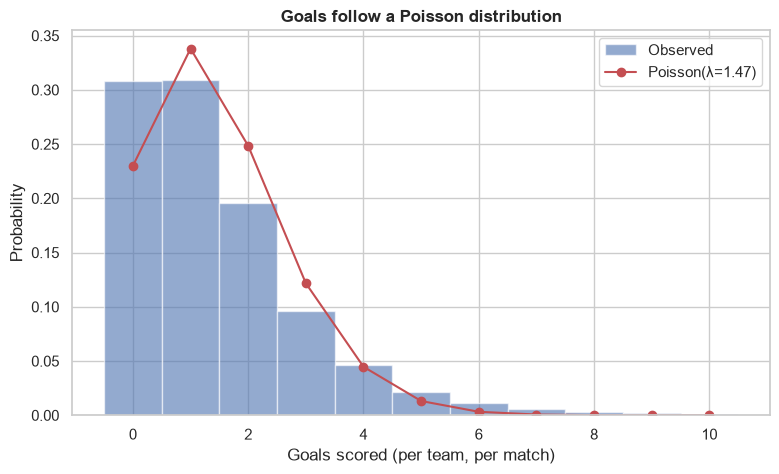

In [2]:
plots.plot_goal_distribution(matches)
plt.show()

The observed bars track the Poisson curve closely — **Poisson is a sound choice** for the score model.

## 2. How big is home advantage?

Validates the `home_advantage = 100` Elo points we chose in Phase 4.

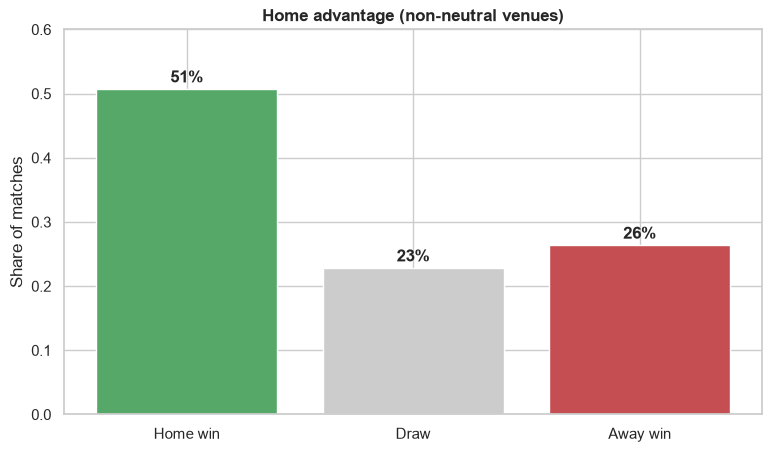

In [3]:
plots.plot_home_advantage(matches)
plt.show()

Home teams win far more often than they lose — a real, large effect. (Note: WC2026 games are at neutral venues, so our Elo correctly zeroes this out for predictions.)

## 3. Is Elo well-calibrated?

When Elo predicts a 0.7 home score, do those teams really average ~0.7? Points on the diagonal = trustworthy probabilities.

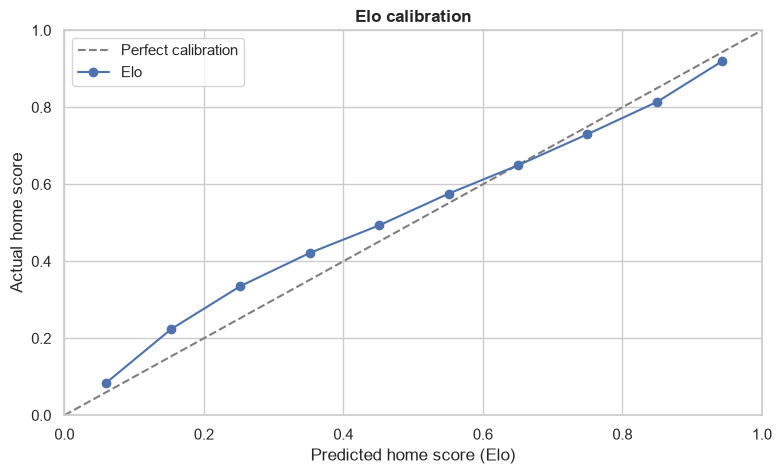

In [4]:
plots.plot_elo_calibration(matches)
plt.show()

## 4. Current Elo & the WC2026 'group of death'

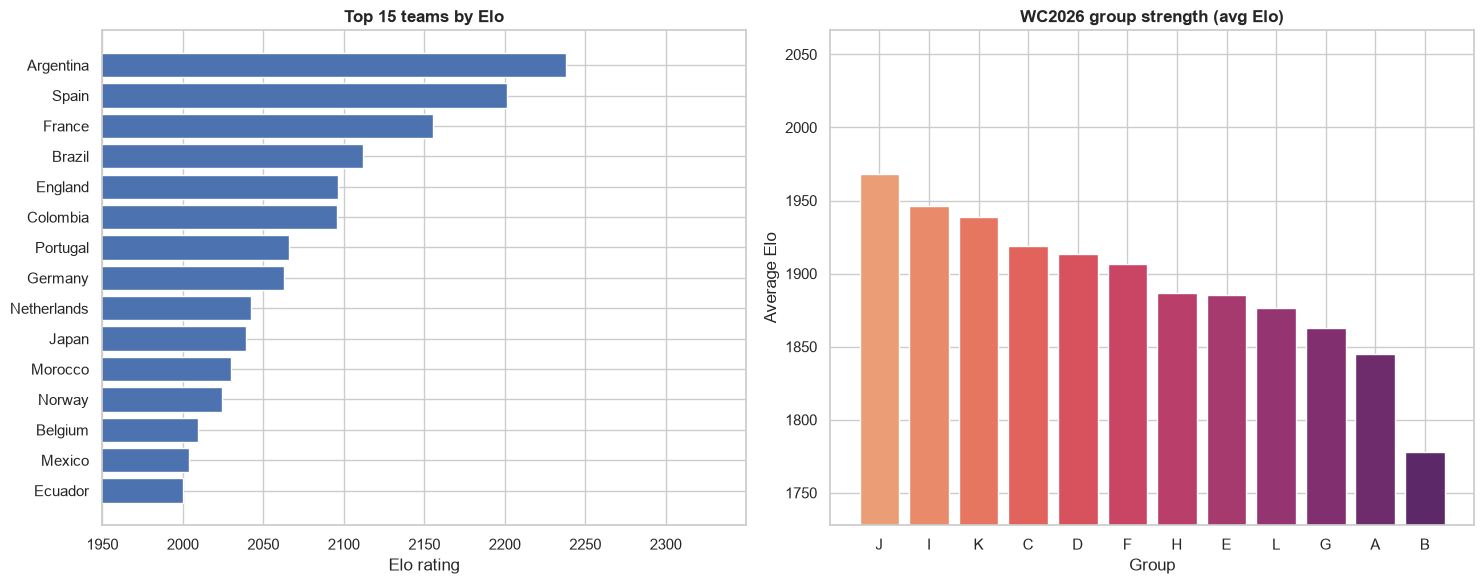

In [5]:
elo = build_current_ratings(save=False)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
plots.plot_top_teams(elo, n=15, ax=ax1)
plots.plot_group_strength(groups, elo, ax=ax2)
plt.tight_layout()
plt.show()

The right-hand chart ranks the 12 groups by average Elo — the tallest bar is the toughest group to escape.

---
### Takeaways feeding the next phases
- **Goals ≈ Poisson** → Phase 9 Poisson score model is justified.
- **Home advantage is large** → already handled by Elo (and zeroed for neutral WC games).
- **Elo is reasonably calibrated** → solid feature for the ML model in Phases 7-8.